# Accessing ARGO data

Initially working from the summary sheet: https://argopy.readthedocs.io/en/latest/_static/argopy-cheatsheet.pdf


In [1]:
# Download a dataset based on longitude, latitude, pressure and time range
from argopy import DataFetcher
fetcher = DataFetcher().region([-75, -45, 20, 30, 0, 100, '2026-02', '2026-04'])

In [2]:
# Alternatively download specific float profiles
fetcher1 = DataFetcher().float([6902746, 6902755])

In [3]:
# Or specific cycles of a given float
fetcher2 = DataFetcher().profile(6902746, [1,12])

In [4]:
# convert to xarray
fetcher.to_xarray()
# gives an error, but can probably be ignored for now since the dataframe and dataset methods work fine

<xarray.Dataset> Size: 1MB
Dimensions:          (N_POINTS: 10700)
Coordinates:
    LATITUDE         (N_POINTS) float64 86kB 26.32 26.32 26.32 ... 23.77 23.77
    LONGITUDE        (N_POINTS) float64 86kB -52.62 -52.62 ... -63.56 -63.56
    TIME             (N_POINTS) datetime64[ns] 86kB 2026-02-01T04:10:19 ... 2...
  * N_POINTS         (N_POINTS) int64 86kB 0 1 2 3 4 ... 10696 10697 10698 10699
Data variables: (12/15)
    CYCLE_NUMBER     (N_POINTS) int64 86kB 152 152 152 152 152 ... 28 28 28 28
    DATA_MODE        (N_POINTS) <U1 43kB 'R' 'R' 'R' 'R' 'R' ... 'R' 'R' 'R' 'R'
    DIRECTION        (N_POINTS) <U1 43kB 'A' 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    PLATFORM_NUMBER  (N_POINTS) int64 86kB 1902316 1902316 ... 4903898 4903898
    POSITION_QC      (N_POINTS) int64 86kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    PRES             (N_POINTS) float32 43kB 1.0 2.0 2.96 ... 96.0 98.0 100.0
    ...               ...
    PSAL_ERROR       (N_POINTS) float32 43kB nan nan nan nan ... nan nan nan nan
    PSAL_QC          (N_POINTS) int64 86kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TEMP             (N_POINTS) float32 43kB 24.62 24.62 24.62 ... 25.77 25.71
    TEMP_ERROR       (N_POINTS) float32 43kB nan nan nan nan ... nan nan nan nan
    TEMP_QC          (N_POINTS) int64 86kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TIME_QC          (N_POINTS) int64 86kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
Attributes:
    DATA_ID:              ARGO
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         erddap.ifremer.fr
    Fetched_by:           ifenton
    Fetched_date:         2026/03/11
    Fetched_constraints:  [x=-75.00/-45.00; y=20.00/30.00; z=0.0/100.0; t=202...
    Fetched_uri:          https://erddap.ifremer.fr/erddap/tabledap/ArgoFloat...
    Processing_history:   [PRES,TEMP,PSAL] real-time and adjusted/delayed var...

In [5]:
# convert to pandas dataframe
fetcher.to_dataframe()

,CYCLE_NUMBER,DATA_MODE,DIRECTION,PLATFORM_NUMBER,POSITION_QC,PRES,PRES_ERROR,PRES_QC,PSAL,PSAL_ERROR,PSAL_QC,TEMP,TEMP_ERROR,TEMP_QC,TIME_QC,LATITUDE,LONGITUDE,TIME
N_POINTS,,,,,,,,,,,,,,,,,,
0,152,R,A,1902316,1,1.000000,NaN,1,37.178001,NaN,1,24.617001,NaN,1,1,26.32144,-52.62372,2026-02-01 04:10:19
1,152,R,A,1902316,1,2.000000,NaN,1,37.175999,NaN,1,24.618000,NaN,1,1,26.32144,-52.62372,2026-02-01 04:10:19
2,152,R,A,1902316,1,2.960000,NaN,1,37.178001,NaN,1,24.620001,NaN,1,1,26.32144,-52.62372,2026-02-01 04:10:19
3,152,R,A,1902316,1,3.960000,NaN,1,37.178001,NaN,1,24.624001,NaN,1,1,26.32144,-52.62372,2026-02-01 04:10:19
4,152,R,A,1902316,1,4.960000,NaN,1,37.178001,NaN,1,24.622000,NaN,1,1,26.32144,-52.62372,2026-02-01 04:10:19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10695,28,R,A,4903898,1,91.959999,NaN,1,37.063000,NaN,1,25.961000,NaN,1,1,23.77454,-63.55563,2026-03-11 05:40:56
10696,28,R,A,4903898,1,94.000000,NaN,1,37.071999,NaN,1,25.931000,NaN,1,1,23.77454,-63.55563,2026-03-11 05:40:56
10697,28,R,A,4903898,1,96.000000,NaN,1,37.103001,NaN,1,25.878000,NaN,1,1,23.77454,-63.55563,2026-03-11 05:40:56


In [24]:
# convert to netcdf dataset (n.b. don't need to go via other formats)
test_nc = fetcher.to_dataset()

In [ ]:
test_nc


IndexError: lat not found in /

In [7]:
# look at the data
fetcher.data

<xarray.Dataset> Size: 1MB
Dimensions:          (N_POINTS: 10700)
Coordinates:
    LATITUDE         (N_POINTS) float64 86kB 26.32 26.32 26.32 ... 23.77 23.77
    LONGITUDE        (N_POINTS) float64 86kB -52.62 -52.62 ... -63.56 -63.56
    TIME             (N_POINTS) datetime64[ns] 86kB 2026-02-01T04:10:19 ... 2...
  * N_POINTS         (N_POINTS) int64 86kB 0 1 2 3 4 ... 10696 10697 10698 10699
Data variables: (12/15)
    CYCLE_NUMBER     (N_POINTS) int64 86kB 152 152 152 152 152 ... 28 28 28 28
    DATA_MODE        (N_POINTS) <U1 43kB 'R' 'R' 'R' 'R' 'R' ... 'R' 'R' 'R' 'R'
    DIRECTION        (N_POINTS) <U1 43kB 'A' 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    PLATFORM_NUMBER  (N_POINTS) int64 86kB 1902316 1902316 ... 4903898 4903898
    POSITION_QC      (N_POINTS) int64 86kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    PRES             (N_POINTS) float32 43kB 1.0 2.0 2.96 ... 96.0 98.0 100.0
    ...               ...
    PSAL_ERROR       (N_POINTS) float32 43kB nan nan nan nan ... nan nan nan nan
    PSAL_QC          (N_POINTS) int64 86kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TEMP             (N_POINTS) float32 43kB 24.62 24.62 24.62 ... 25.77 25.71
    TEMP_ERROR       (N_POINTS) float32 43kB nan nan nan nan ... nan nan nan nan
    TEMP_QC          (N_POINTS) int64 86kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TIME_QC          (N_POINTS) int64 86kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
Attributes:
    DATA_ID:              ARGO
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         erddap.ifremer.fr
    Fetched_by:           ifenton
    Fetched_date:         2026/03/11
    Fetched_constraints:  [x=-75.00/-45.00; y=20.00/30.00; z=0.0/100.0; t=202...
    Fetched_uri:          https://erddap.ifremer.fr/erddap/tabledap/ArgoFloat...
    Processing_history:   [PRES,TEMP,PSAL] real-time and adjusted/delayed var...

In [8]:
# data index
fetcher.index

,date,latitude,longitude,wmo,cyc
0,2026-02-21 10:24:28,27.48458,-73.55472,4903922,31
1,2026-02-11 22:26:46,27.91675,-73.46419,4903922,30
2,2026-02-02 10:44:58,28.30716,-73.28441,4903922,29
3,2026-02-23 08:26:55,28.55100,-60.43921,4902322,227
4,2026-02-08 03:59:57,28.61777,-60.39760,4902322,226
...,...,...,...,...,...
177,2026-03-08 18:09:19,24.84870,-54.08850,7902226,43
178,2026-02-02 18:09:00,22.69616,-62.73172,7902278,25
179,2026-02-13 00:45:14,22.84734,-62.90113,7902278,26
180,2026-02-23 07:40:48,23.15431,-62.92138,7902278,27


# Setting the user mode

Defaults to `standard`, but can also choose `research` or `expert`

Select with global option setter:
`argopy.set_options(mode='expert')`
Select in a temporary context:
```
with argopy.set_options(mode='expert'):
    DataFetcher().profile(6902746, 34)
```
Select with fetcher options:
`DataFetcher(mode='research').region([-75, -45, 20, 30, 0, 100])`


# Plotting

(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='longitude', ylabel='latitude'>)

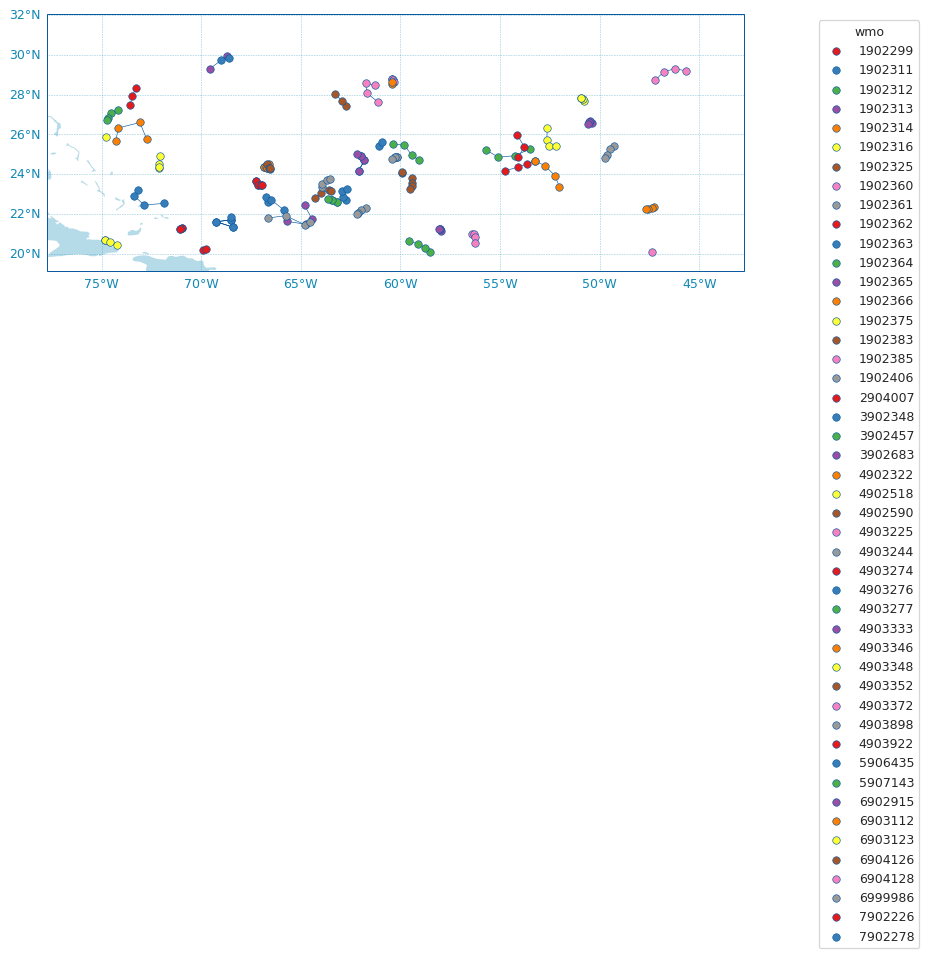

In [9]:
fetcher.plot()

(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='longitude', ylabel='latitude'>)

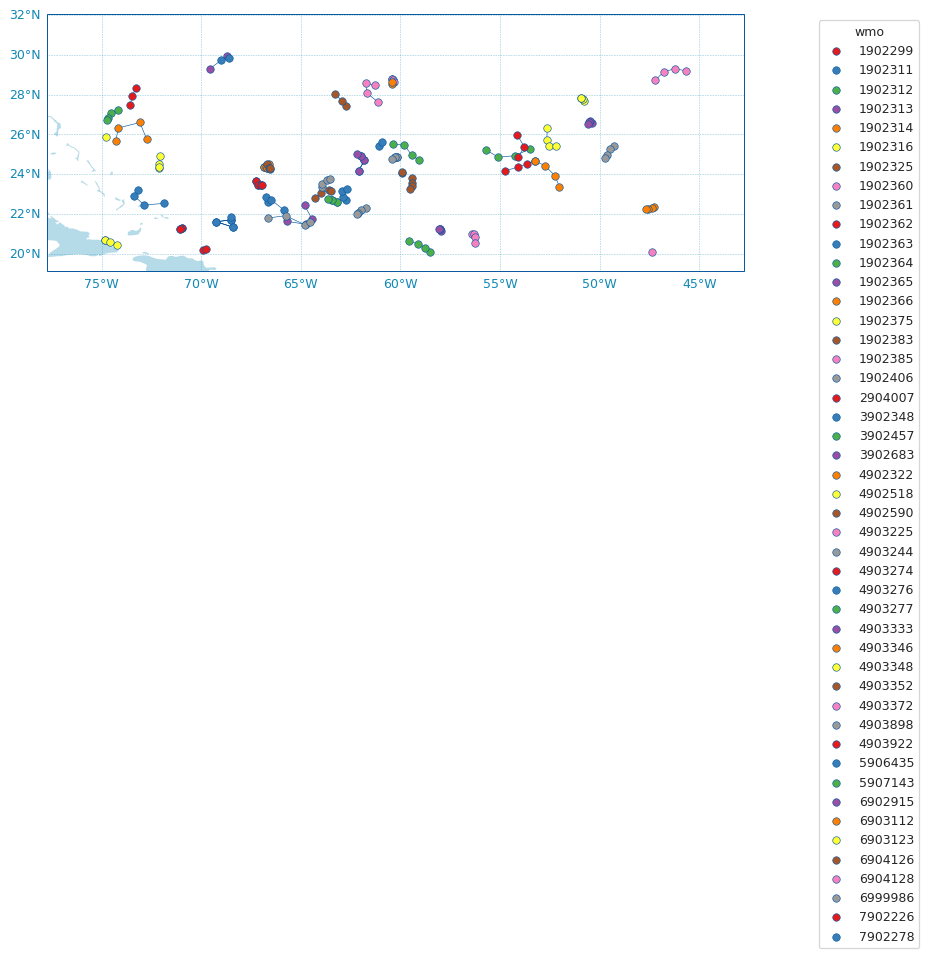

In [10]:
fetcher.plot('trajectory')


(<Figure size 900x540 with 1 Axes>, <Axes: xlabel='Number of profiles'>)

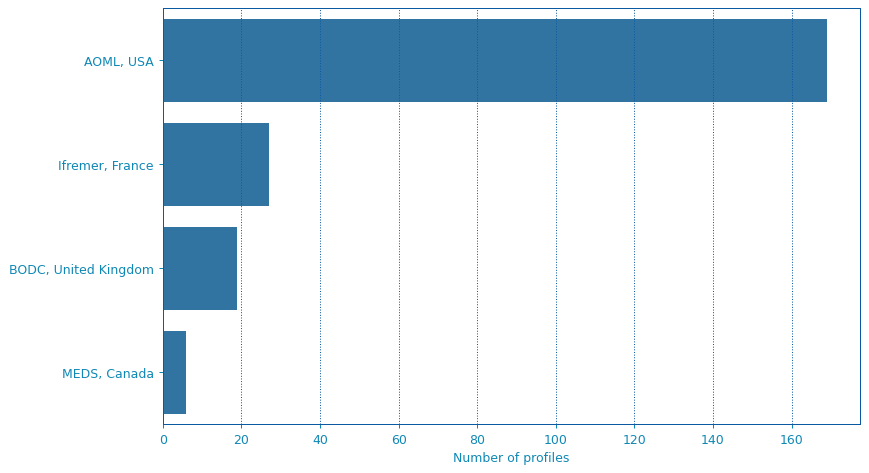

In [11]:
fetcher.plot('dac')


(<Figure size 900x540 with 1 Axes>, <Axes: xlabel='Number of profiles'>)

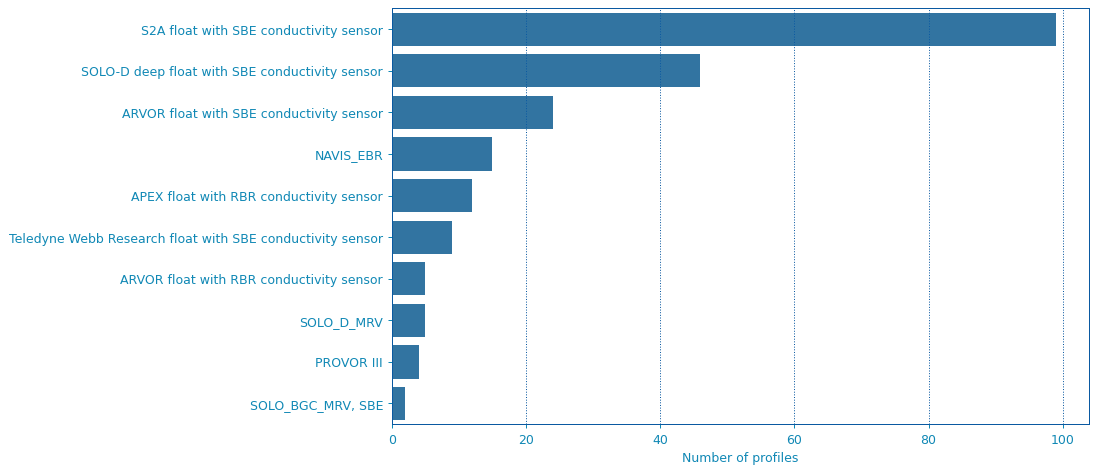

In [12]:
fetcher.plot('profiler')


(<Figure size 900x540 with 2 Axes>,
 <GeoAxes: title={'center': 'Argo float WMO: 6902746'}, xlabel='Longitude of the station, best\nestimate [degree_east]', ylabel='Latitude of the station, best\nestimate [degree_north]'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0x17f3d1e10>,
  'cbar': <matplotlib.colorbar.Colorbar at 0x30a270cd0>,
  'legend': None,
  'traj': [<matplotlib.lines.Line2D at 0x17f3c0f50>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0x3081bb3d0>})

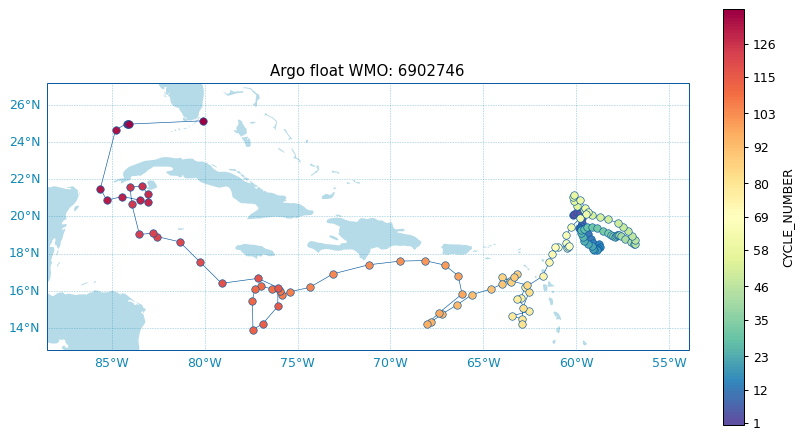

In [13]:
# ArgoFloat
from argopy import ArgoFloat
af = ArgoFloat(6902746)
af.plot.trajectory()


/Users/ifenton/Documents/Projects/SeaIce/icenet-mp/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2650: RuntimeWarning: invalid value encountered in cast
  output[index] = result


(<Figure size 900x540 with 2 Axes>,
 <GeoAxes: title={'center': 'Argo float WMO: 6902746'}, xlabel='Longitude of the station, best\nestimate [degree_east]', ylabel='Latitude of the station, best\nestimate [degree_north]'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0x17f401ad0>,
  'cbar': <matplotlib.colorbar.Colorbar at 0x30a2a2cd0>,
  'legend': None,
  'traj': [<matplotlib.lines.Line2D at 0x30a35c050>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0x3081eae90>})

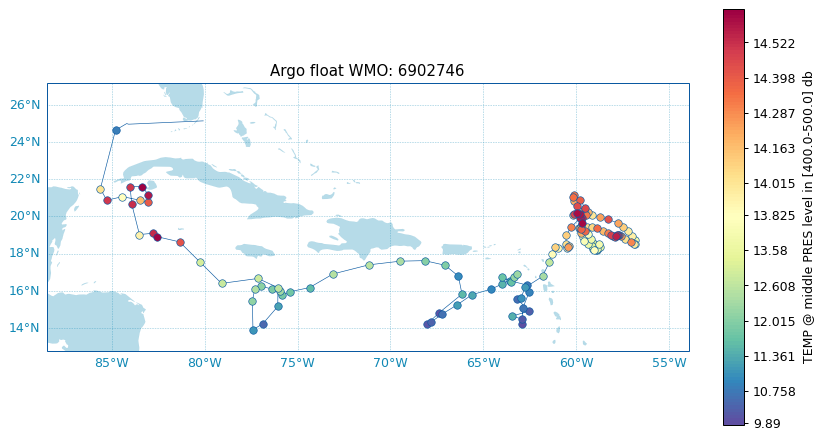

In [14]:
af.plot.map('TEMP', pres=450)


(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='Longitude of the station, best\nestimate', ylabel='Latitude of the station, best\nestimate'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0x308409ad0>,
  'cbar': None,
  'legend': <matplotlib.legend.Legend at 0x30a373290>,
  'traj': [<matplotlib.lines.Line2D at 0x30aa02c50>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0x3086f1a10>})

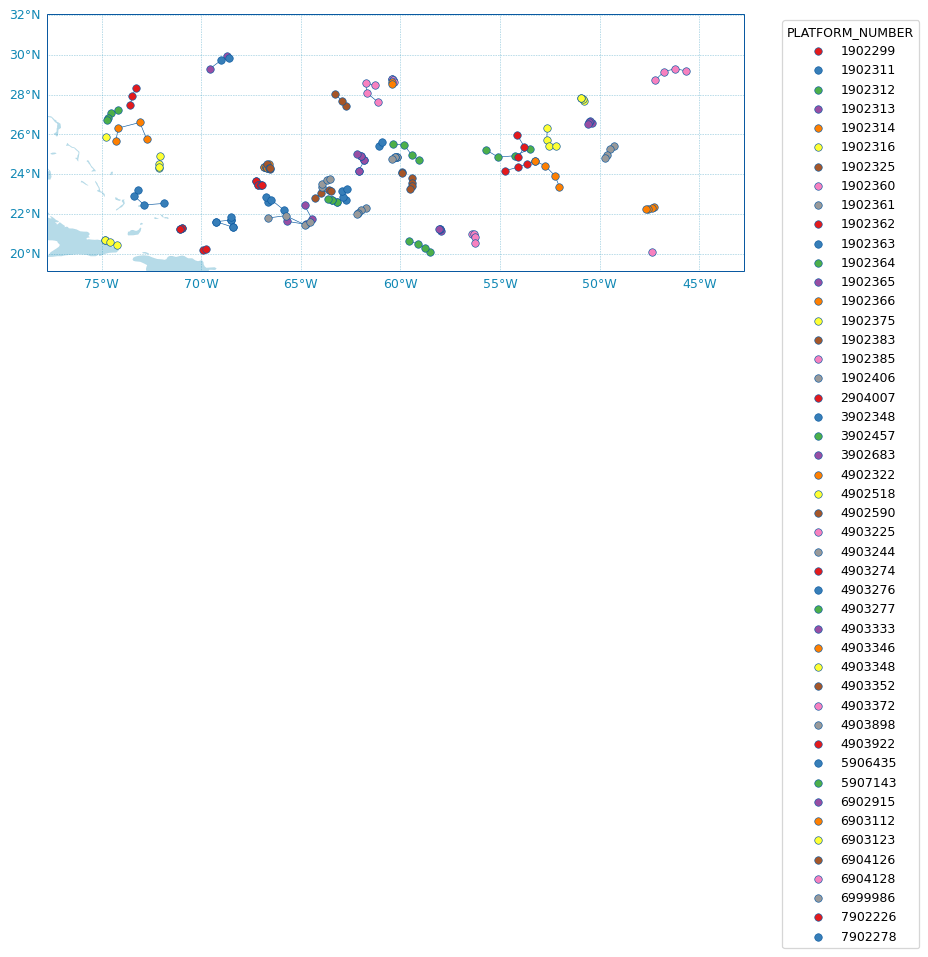

In [15]:
from argopy.plot import scatter_map
ds = fetcher.data.argo.point2profile()
scatter_map(ds)


(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='Longitude of the station, best\nestimate', ylabel='Latitude of the station, best\nestimate'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0x30ac23190>,
  'cbar': None,
  'legend': <matplotlib.legend.Legend at 0x30aabd710>,
  'traj': [<matplotlib.lines.Line2D at 0x30ac8dad0>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0x30a21fc50>})

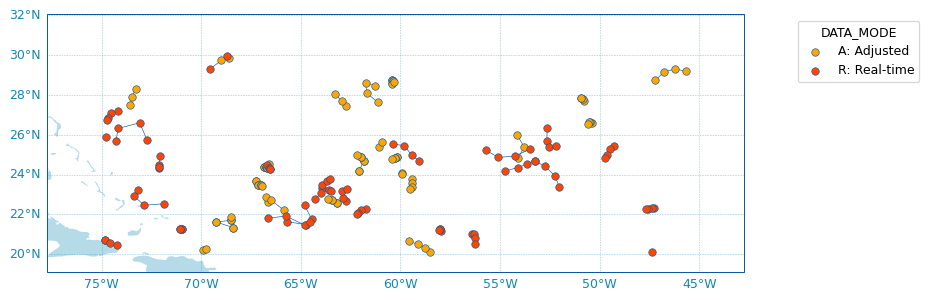

In [16]:
scatter_map(ds, hue='DATA_MODE')


(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='Longitude of the station, best\nestimate', ylabel='Latitude of the station, best\nestimate'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0x30a94f650>],
  'cbar': None,
  'legend': <matplotlib.legend.Legend at 0x30acbba50>,
  'traj': [<matplotlib.lines.Line2D at 0x30ad58190>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0x30ac02490>})

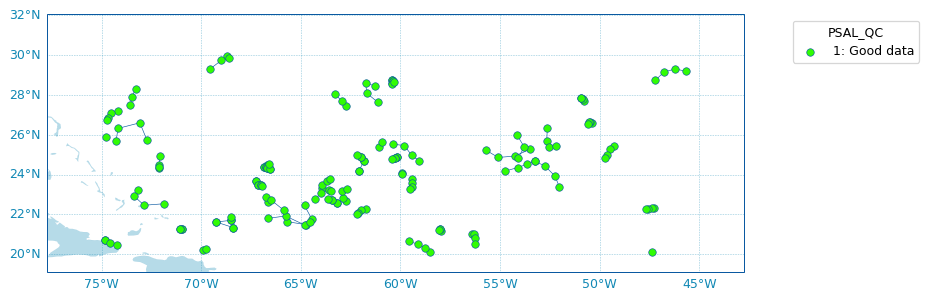

In [17]:
scatter_map(ds.isel(N_LEVELS=0), hue='PSAL_QC')


(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='Longitude of the station, best\nestimate', ylabel='Latitude of the station, best\nestimate'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0x14f12cc50>],
  'cbar': None,
  'legend': <matplotlib.legend.Legend at 0x17f2c7910>,
  'traj': [<matplotlib.lines.Line2D at 0x17f67f950>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0x30aca9b50>})

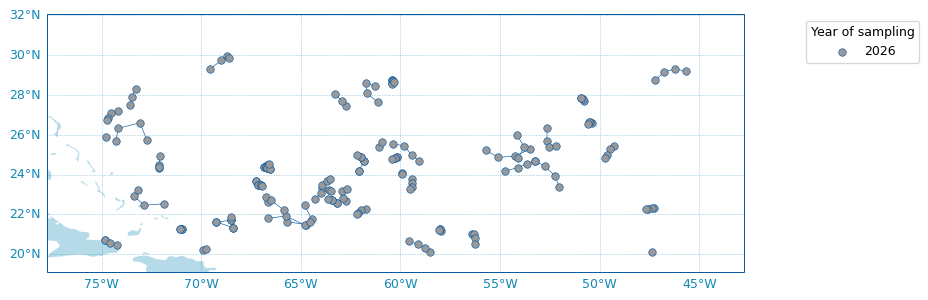

In [18]:
ds['year'] = ds['TIME.year'] # Add a variable
scatter_map(ds.isel(N_LEVELS=0),
hue='year',
legend_title='Year of sampling')

# Potentially useful data

In [19]:
test_data = DataFetcher().region([-180, 180, 70, 90, 0, 5, '2011-01', '2011-06'])
test_data.to_dataframe()

,CYCLE_NUMBER,DATA_MODE,DIRECTION,PLATFORM_NUMBER,POSITION_QC,PRES,PRES_ERROR,PRES_QC,PSAL,PSAL_ERROR,PSAL_QC,TEMP,TEMP_ERROR,TEMP_QC,TIME_QC,LATITUDE,LONGITUDE,TIME
N_POINTS,,,,,,,,,,,,,,,,,,
0,62,D,A,6901387,1,4.30,2.4,1,35.066002,0.01,1,2.839,0.002,1,1,79.0439,4.71669,2011-01-01 11:54:33
1,63,D,A,6901387,1,2.60,2.4,1,35.053001,0.01,1,2.764,0.002,1,1,79.1290,4.18030,2011-01-04 11:57:07
2,63,D,A,6901387,1,4.80,2.4,1,35.053001,0.01,1,2.764,0.002,1,1,79.1290,4.18030,2011-01-04 11:57:07
3,7,D,A,6900799,1,3.36,2.4,1,35.221699,0.01,1,6.009,0.002,1,1,70.4540,5.17500,2011-01-04 23:41:17
4,7,D,A,6900799,1,4.56,2.4,1,35.221722,0.01,1,6.008,0.002,1,1,70.4540,5.17500,2011-01-04 23:41:17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,206,D,A,6900345,1,4.80,2.4,1,35.048000,0.01,1,2.457,0.002,1,1,76.9740,5.92800,2011-05-28 07:08:13
78,33,D,A,6900810,1,2.40,2.4,1,34.840000,0.01,1,7.244,0.002,1,1,70.0180,14.83700,2011-05-28 09:19:06
79,111,D,A,6901387,1,0.50,2.4,1,34.745998,0.01,1,0.910,0.002,1,1,74.9212,-4.13467,2011-05-28 12:38:17


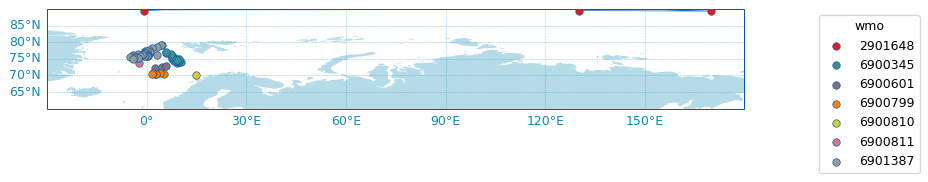

In [20]:
import matplotlib.pyplot as plt

# Create a figure and axes with specific limits
scatter_map(test_data.index)
plt.xlim(-30, 180)  # longitude limits
plt.ylim(60, 90)   # latitude limits
plt.show()

In [21]:
test_data_SH = DataFetcher().region([-180, 180, -90, -70, 0, 5, '2026-01', '2026-03'])
test_data_SH.to_dataframe()

,CYCLE_NUMBER,DATA_MODE,DIRECTION,PLATFORM_NUMBER,POSITION_QC,PRES,PRES_ERROR,PRES_QC,PSAL,PSAL_ERROR,PSAL_QC,TEMP,TEMP_ERROR,TEMP_QC,TIME_QC,LATITUDE,LONGITUDE,TIME
N_POINTS,,,,,,,,,,,,,,,,,,
0,41,R,A,5907097,1,3.0,NaN,1,34.153000,NaN,1,-1.590,NaN,1,1,-75.188488,-29.992770,2026-01-01 01:44:00
1,41,R,A,5907097,1,4.0,NaN,1,34.153999,NaN,1,-1.601,NaN,1,1,-75.188488,-29.992770,2026-01-01 01:44:00
2,41,R,A,5907097,1,5.0,NaN,1,34.153999,NaN,1,-1.606,NaN,1,1,-75.188488,-29.992770,2026-01-01 01:44:00
3,46,R,A,1902769,1,3.8,NaN,1,34.389000,NaN,1,0.190,NaN,1,1,-77.374667,176.205290,2026-01-01 05:37:00
4,165,R,A,6903832,1,3.4,NaN,1,34.292000,NaN,1,0.114,NaN,1,1,-77.077137,173.023917,2026-01-01 05:50:20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456,56,R,A,6990712,1,3.9,NaN,1,34.231998,NaN,1,-1.596,NaN,1,1,-77.318330,174.224105,2026-02-28 05:13:20
457,224,A,A,6903770,1,3.5,NaN,1,33.592999,NaN,1,-1.300,NaN,1,1,-72.325427,-154.322785,2026-02-28 09:20:30
458,47,R,A,5907097,1,3.0,NaN,1,33.907001,NaN,1,-1.220,NaN,1,1,-75.230602,-30.163117,2026-02-28 19:42:00


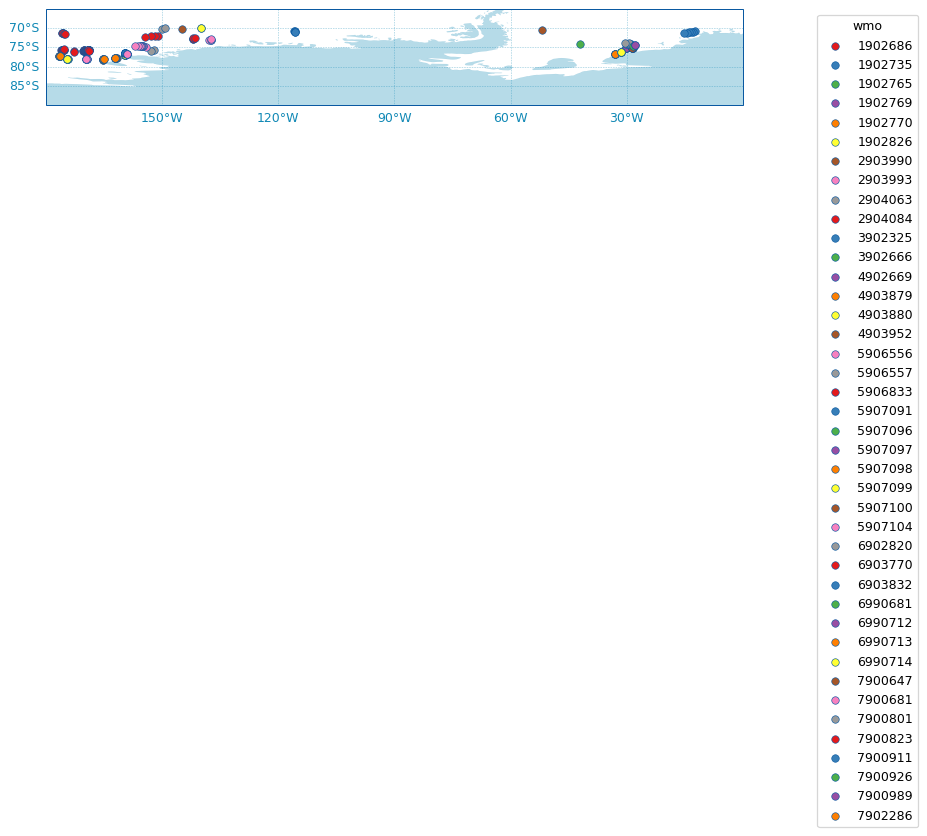

In [22]:
scatter_map(test_data_SH.index)
plt.xlim(-180, 0)  # longitude limits
plt.ylim(-90, -65)   # latitude limits
plt.show()

In [23]:
test_data.to_xarray().argo.to_zarr("../../zebra_anemoi/test_sample.zarr")

ContainsGroupError: path '' contains a group